## Dawn Andrei Pamesa
## TS31

Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

Loading the Dataset

In [2]:
df = pd.read_excel("Customer_Satisfaction.xlsx", sheet_name="Survey Responses")
df.head()

,id,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1,5,6,4,7,4,6,6,4,4,4,4,4,3,NaN,NaN,1) Get the correlation of perception indicato...
1,6,3,5,6,6,6,5,7,4,7,4,6,5,5,NaN,NaN,and likelihood to recommend.
2,7,4,6,4,6,4,6,6,3,4,4,4,3,2,NaN,NaN,NaN
3,9,5,5,5,7,4,5,6,4,6,7,7,7,6,NaN,NaN,NaN
4,10,4,6,5,7,5,6,7,4,6,7,6,6,6,NaN,NaN,NaN


Survey Questions

In [3]:
questions = pd.read_excel("Customer_Satisfaction.xlsx", sheet_name="Questions", usecols="A:B")
questions

,Questions :,Unnamed: 1
0,x12,has friendly employees
1,x13,is a fun place to eat
2,x14,has large size portions
3,x15,has fresh food
4,x16,has reasonable prices
5,x17,has an attractive interior
6,x18,has excellent food taste
7,x19,has knowledgeable employees
8,x20,serves food at the proper temperature
9,x21,has quick service


Select Columns

In [4]:
df = df[["id", "x12", "x13", "x14", "x15", "x16", "x17", "x18", "x19", "x20", "x21", "x22", "x23", "x24"]]
df.head()

,id,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24
0,1,5,6,4,7,4,6,6,4,4,4,4,4,3
1,6,3,5,6,6,6,5,7,4,7,4,6,5,5
2,7,4,6,4,6,4,6,6,3,4,4,4,3,2
3,9,5,5,5,7,4,5,6,4,6,7,7,7,6
4,10,4,6,5,7,5,6,7,4,6,7,6,6,6


Check Missing Values

In [5]:
print(df.isnull().sum())
print("Duplicate ids:", df["id"].duplicated().sum())

id     0
x12    0
x13    0
x14    0
x15    0
x16    0
x17    0
x18    0
x19    0
x20    0
x21    0
x22    0
x23    0
x24    0
dtype: int64
Duplicate ids: 0


Descriptive Statistics

In [6]:
df.drop(columns="id").describe()

,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,3.639506,4.637037,4.508642,5.762963,4.338272,4.696296,5.311111,3.553086,4.523457,5.209877,4.829630,4.464198,3.785185
std,1.209869,0.908764,1.323081,1.195334,1.237469,1.019178,1.084088,1.517316,1.167874,2.038710,1.118305,1.104369,1.198505
min,1.000000,2.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000
25%,2.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000,3.000000,4.000000,3.000000,4.000000,4.000000,3.000000
50%,4.000000,5.000000,5.000000,6.000000,4.000000,5.000000,5.000000,4.000000,5.000000,7.000000,5.000000,4.000000,4.000000
75%,5.000000,5.000000,6.000000,7.000000,5.000000,5.000000,6.000000,4.000000,5.000000,7.000000,6.000000,5.000000,5.000000
max,5.000000,7.000000,6.000000,7.000000,6.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


## Part A: Correlation

Correlation Matrix

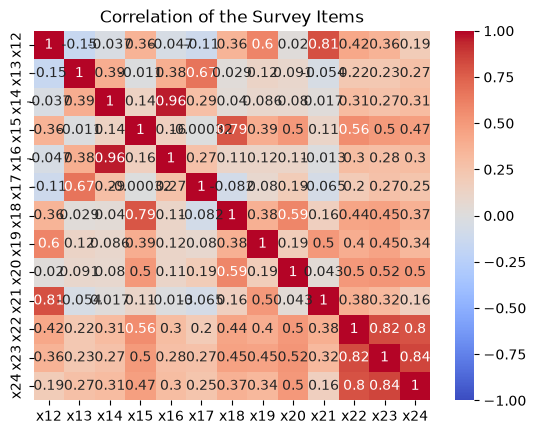

In [7]:
corr = df.drop(columns="id").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of the Survey Items")
plt.show()

Correlation with Satisfaction, Return and Recommend

In [8]:
corr[["x22", "x23", "x24"]].drop(["x22", "x23", "x24"])

,x22,x23,x24
x12,0.424663,0.360823,0.190568
x13,0.219096,0.225022,0.273674
x14,0.307976,0.268291,0.307903
x15,0.558553,0.496072,0.470610
x16,0.297525,0.281472,0.304467
x17,0.195553,0.272906,0.248394
x18,0.439920,0.453833,0.371618
x19,0.397019,0.446132,0.335002
x20,0.504357,0.517384,0.504953
x21,0.383769,0.323816,0.163361


Significance of the Correlation with Satisfaction

In [9]:
for col in ["x12", "x13", "x14", "x15", "x16", "x17", "x18", "x19", "x20", "x21"]:
    r, p = stats.pearsonr(df[col], df["x22"])
    print(col, "r =", round(r, 3), "p =", p)

x12 r = 0.425 p = 3.661072144249256e-19
x13 r = 0.219 p = 8.595755580055164e-06
x14 r = 0.308 p = 2.399199239217991e-10
x15 r = 0.559 p = 1.3365845429659199e-34
x16 r = 0.298 p = 1.0093418399832852e-09
x17 r = 0.196 p = 7.445354384592545e-05
x18 r = 0.44 p = 1.3453271894821238e-20
x19 r = 0.397 p = 9.640304198684843e-17
x20 r = 0.504 p = 1.606871395860792e-27
x21 r = 0.384 p = 1.165713567342377e-15


## Part B: One-Way ANOVA

Research Question and Hypotheses

Research question: Does customer satisfaction (x22) differ across the ratings of fresh food (x15)?

- H0: The mean satisfaction is the same for every fresh food rating.
- H1: At least one fresh food rating has a different mean satisfaction.

x15 (fresh food) is the independent variable and is used as the groups. x22 (satisfaction) is the dependent variable. Both are ratings from 1 to 7. Fresh food was picked because it has the highest correlation with satisfaction in Part A.

Choosing the Test

In [10]:
df["x15"].value_counts().sort_index()

x15
4     85
5     93
6     60
7    167
Name: count, dtype: int64

The fresh food ratings only go from 4 to 7, so there are four groups. A one-way ANOVA is used since the mean satisfaction of three or more groups is being compared. A t-test can only compare two groups, and a Chi-square test is for two categorical variables.

Splitting the Groups

In [11]:
g4 = df[df["x15"] == 4]["x22"]
g5 = df[df["x15"] == 5]["x22"]
g6 = df[df["x15"] == 6]["x22"]
g7 = df[df["x15"] == 7]["x22"]

df.groupby("x15")["x22"].describe()

,count,mean,std,min,25%,50%,75%,max
x15,,,,,,,,
4,85.0,3.988235,0.587450,3.0,4.0,4.0,4.0,6.0
5,93.0,4.354839,0.775230,3.0,4.0,4.0,5.0,6.0
6,60.0,4.850000,1.286501,3.0,4.0,5.0,6.0,7.0
7,167.0,5.514970,0.993086,4.0,5.0,6.0,6.0,7.0


Checking Normality (Shapiro-Wilk)

In [12]:
print("Rating 4:", stats.shapiro(g4))
print("Rating 5:", stats.shapiro(g5))
print("Rating 6:", stats.shapiro(g6))
print("Rating 7:", stats.shapiro(g7))

Rating 4: ShapiroResult(statistic=np.float64(0.580374354049404), pvalue=np.float64(3.245111132689736e-14))
Rating 5: ShapiroResult(statistic=np.float64(0.8137370431813441), pvalue=np.float64(1.7616896812071658e-09))
Rating 6: ShapiroResult(statistic=np.float64(0.903368112254819), pvalue=np.float64(0.00017488510184753006))
Rating 7: ShapiroResult(statistic=np.float64(0.8559042850831157), pvalue=np.float64(1.591492319839084e-11))


Checking Equal Variances (Levene)

In [13]:
print(stats.levene(g4, g5, g6, g7))

LeveneResult(statistic=np.float64(19.141202880568297), pvalue=np.float64(1.2793593365291254e-11))


Boxplot per Group

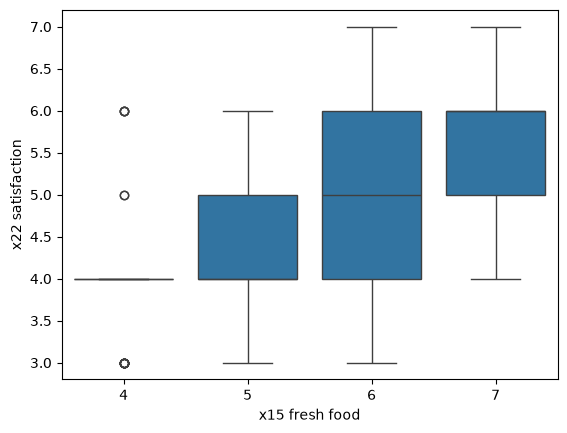

In [14]:
sns.boxplot(x="x15", y="x22", data=df)
plt.xlabel("x15 fresh food")
plt.ylabel("x22 satisfaction")
plt.show()

All p-values are below 0.05, so normality and equal variances are both not met. However, each group has at least 60 respondents, so the ANOVA can still be used, and this is noted as a limitation.

Running the One-Way ANOVA

In [15]:
f_stat, p_value = stats.f_oneway(g4, g5, g6, g7)
print("F statistic:", f_stat)
print("p-value:", p_value)

F statistic: 61.7219440819865
p-value: 7.92036496670449e-33


Degrees of Freedom

In [16]:
df_between = 4 - 1
df_within = len(df) - 4
print("df between:", df_between)
print("df within:", df_within)

df between: 3
df within: 401


Effect Size (Eta Squared)

In [17]:
grand_mean = df["x22"].mean()

ss_between = 0
for g in [g4, g5, g6, g7]:
    ss_between = ss_between + len(g) * (g.mean() - grand_mean) ** 2

ss_total = ((df["x22"] - grand_mean) ** 2).sum()

eta_squared = ss_between / ss_total
print("Eta squared:", eta_squared)

Eta squared: 0.315893254194766


Plotting the Mean Satisfaction per Group

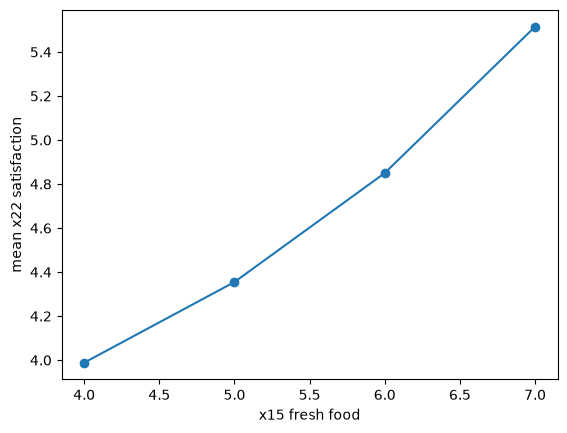

In [18]:
means = df.groupby("x15")["x22"].mean()

plt.plot(means.index, means.values, marker="o")
plt.xlabel("x15 fresh food")
plt.ylabel("mean x22 satisfaction")
plt.show()

Summary

In [19]:
print("\nSummary")
print("F(3, 401):", round(f_stat, 2))
print("p-value:", p_value)
print("Eta squared:", round(eta_squared, 3))
print("Mean satisfaction per rating:", means.round(2).tolist())

if p_value < 0.05:
    print("\nReject H0. The mean satisfaction is different across the fresh food ratings.")
else:
    print("\nFail to reject H0. There is no significant difference in mean satisfaction.")
print("The mean satisfaction goes up as the fresh food rating goes up.")
print("Eta squared shows that fresh food explains about a third of the variation in satisfaction.")


Summary
F(3, 401): 61.72
p-value: 7.92036496670449e-33
Eta squared: 0.316
Mean satisfaction per rating: [3.99, 4.35, 4.85, 5.51]

Reject H0. The mean satisfaction is different across the fresh food ratings.
The mean satisfaction goes up as the fresh food rating goes up.
Eta squared shows that fresh food explains about a third of the variation in satisfaction.


Bulleted Analysis

- Dataset: 405 respondents and 13 survey items rated from 1 to 7, with no missing values and no duplicate ids.
- Part A: all ten perceptions have a positive and significant correlation with satisfaction (p < 0.05).
- Fresh food has the highest correlation with satisfaction (r = 0.56), followed by proper food temperature (r = 0.50). Attractive interior is the lowest (r = 0.20).
- Part B: the one-way ANOVA shows that mean satisfaction is different across the fresh food ratings, F(3, 401) = 61.72, p < 0.001, so H0 is rejected.
- Mean satisfaction goes up at every rating: 3.99, 4.35, 4.85 and 5.51 for ratings 4 to 7.
- Assumptions: normality (Shapiro-Wilk) and equal variances (Levene) are both not met. The groups are large (60 to 167 respondents), so this is noted as a limitation.
- Practical importance: eta squared = 0.32, a large effect. The difference between rating 4 and rating 7 is 1.53 points on a 7-point scale.
- Limitations: this is survey data, so it only shows association and not cause. Fresh food and food taste are also highly correlated (r = 0.79), and nobody rated fresh food below 4.
- Next step: separate fresh food from food taste, for example by comparing satisfaction across the fresh food ratings among customers who gave the same taste rating.

AI Use

The AI tool used is Claude Code (Claude Opus 5.5). It was used to write and run the Python code and to draft the bulleted analysis, which were then checked.

Prompts used:

1. Build the M2 Technical analysis with the code executed so every number comes from real output. (paraphrased)
2. The dataset is Customer_Satisfaction.xlsx and I am doing the analysis for this dataset.
3. Rewrite it to follow the way we code in our class notebooks and keep it basic, using only the one procedure the guideline asks for. (paraphrased)

Verification:

1. Every number in the bulleted analysis was checked against the output of the code above.
2. The same analysis was also done in Excel with formulas, and the values matched.

Corrections:

1. The raw sheet has the instructor's task note in extra columns, so only the id and x12 to x24 were kept.
2. An earlier version had extra tests and chart styling that were not part of the class, so they were removed.